In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)


True

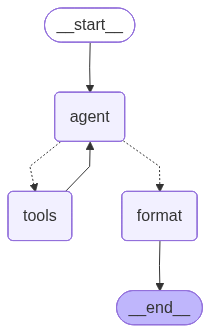

In [2]:
from graph import graph
from IPython.display import Image, display

png = graph.get_graph().draw_mermaid_png()
with open("graph.png", "wb") as f:
    f.write(png)
display(Image(png))

In [3]:
from langchain_core.messages import HumanMessage

def run_test(q):
    print(f"\n{'='*70}\n❓ {q}\n{'='*70}")
    final = None
    for event in graph.stream(
        {"messages": [HumanMessage(content=q)], "tool_call_trace": []},
        stream_mode="values",
    ):
        event["messages"][-1].pretty_print()
        final = event
    print("\n📋 Tools used:", [t["tool"] for t in final.get("tool_call_trace", [])])


In [4]:
run_test("Abigail 생일이 언제야? 좋아하는 선물도 알려줘")


❓ Abigail 생일이 언제야? 좋아하는 선물도 알려줘
================================ Human Message =================================

Abigail 생일이 언제야? 좋아하는 선물도 알려줘
================================== Ai Message ==================================
Tool Calls:
  get_npc_info (call_wAaBPFhQEziP3arhQXbjWNaK)
 Call ID: call_wAaBPFhQEziP3arhQXbjWNaK
  Args:
    npc_name: Abigail
================================= Tool Message =================================
Name: get_npc_info

=== Abigail ===
생일: Fall 13
좋아하는 선물: Amethyst, Banana Pudding, Blackberry Cobbler, Chocolate Cake, Pufferfish, Pumpkin, Spicy Eel
기본 위치: Pierre's General Store
하트 이벤트: {2: '방에서 일어나는 이벤트', 4: '묘지 이벤트', 6: '기타 연주 이벤트', 8: '동굴 탐험 이벤트', 10: '결혼 가능'}
================================== Ai Message ==================================

Abigail의 생일은 가을 13일이에요. 그녀가 좋아하는 선물은 자수정(Amethyst), 바나나 푸딩, 블랙베리 코블러, 초콜릿 케이크, 복어, 호박, 매운 장어(Spicy Eel)입니다. 도움이 필요하면 언제든지 물어보세요!
================================== Ai Message ==================================

Abiga

In [5]:
run_test("봄 시즌이고 예산 1500골드인데 뭐 심으면 좋아?")


❓ 봄 시즌이고 예산 1500골드인데 뭐 심으면 좋아?
================================ Human Message =================================

봄 시즌이고 예산 1500골드인데 뭐 심으면 좋아?
================================== Ai Message ==================================
Tool Calls:
  optimize_crop_profit (call_BxcoD7tJllMJI4WAws0tGRje)
 Call ID: call_BxcoD7tJllMJI4WAws0tGRje
  Args:
    season: Spring
    budget_g: 1500
================================= Tool Message =================================
Name: optimize_crop_profit

=== Spring 예산 1500g 작물 수익 분석 ===
- Strawberry: 순이익 9,300g (씨앗 15개 × 6회 수확) — Egg Festival에서만 씨앗 구매 가능
- Potato: 순이익 8,100g (씨앗 30개 × 4회 수확)
- Cauliflower: 순이익 4,860g (씨앗 18개 × 2회 수확)
================================== Ai Message ==================================

봄 시즌에 예산 1500골드로 심으면 좋은 작물은 다음과 같아요.

1. 감자 (Potato) - 씨앗 30개로 4회 수확 가능, 순이익 약 8,100골드
2. 콜리플라워 (Cauliflower) - 씨앗 18개로 2회 수확 가능, 순이익 약 4,860골드
3. 딸기 (Strawberry) - 에그 페스티벌에서만 씨앗 구매 가능, 6회 수확으로 순이익 약 9,300골드

딸기는 수확 횟수와 수익이 가장 높지만, 씨앗을 에그 페스티벌에서만 살 

In [6]:
run_test("스타듀밸리는 어떤 게임이야?")  # 도구 안 쓰는 케이스 — 라우팅 분기 검증용


❓ 스타듀밸리는 어떤 게임이야?
================================ Human Message =================================

스타듀밸리는 어떤 게임이야?
================================== Ai Message ==================================

스타듀밸리(Stardew Valley)는 농장을 경영하며 마을 사람들과 교류하고, 작물을 키우고, 낚시하고, 광산 탐험도 할 수 있는 힐링 농장 시뮬레이션 게임이에요. 플레이어는 낡은 농장을 물려받아 씨앗을 심고, 동물을 키우고, 마을 사람들과 친해지면서 마을 축제에도 참여할 수 있답니다. 자유도가 높고 다양한 콘텐츠가 있어서 자신만의 농장 생활을 즐길 수 있어요!
================================== Ai Message ==================================

스타듀밸리(Stardew Valley)는 농장을 경영하며 작물을 키우고, 동물을 돌보며, 마을 사람들과 교류하고, 낚시와 광산 탐험 등 다양한 활동을 즐길 수 있는 힐링 농장 시뮬레이션 게임입니다. 플레이어는 낡은 농장을 물려받아 자신만의 농장 생활을 꾸려나가며 마을 축제에도 참여할 수 있습니다. 자유도가 높고 다양한 콘텐츠로 많은 사랑을 받고 있는 게임입니다.

---
📊 사용 도구: 없음
🧠 추론: 사용자의 질문에 대해 스타듀밸리 게임의 주요 특징과 플레이어가 할 수 있는 활동들을 종합하여 설명함으로써 게임의 전반적인 내용을 이해하기 쉽게 전달하고자 하였음.
✅ 확신도: 95%

📋 Tools used: []
